In [120]:
!pip install catboost

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report,roc_auc_score
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import shap


In [122]:
df=pd.read_csv('../Dataset.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Отчистка Датасета


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The figure layout has changed to tight


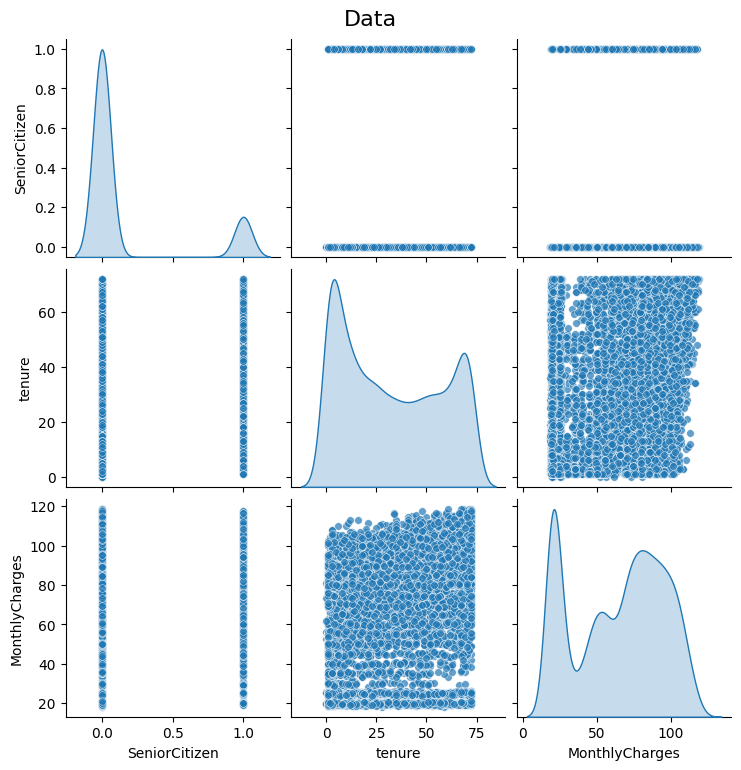

In [124]:
sns.pairplot(data=df,diag_kind='kde', plot_kws={'alpha': 0.7, 's': 30},  height=2.5)
plt.suptitle("Data", y=1.02, fontsize=16)
plt.show()

График показывает распределение и взаимосвязи между признаками SeniorCitizen, tenure и MonthlyCharges. Видно, что большинство клиентов не являются пенсионерами, что указывает на дисбаланс признака SeniorCitizen. Переменная tenure имеет неоднородное распределение: выделяются как новые клиенты с малым стажем, так и клиенты с длительным сроком обслуживания. Распределение MonthlyCharges содержит несколько пиков, что, вероятно, связано с различными тарифными планами. Явной зависимости между стажем клиента и ежемесячной платой не наблюдается. Также не видно существенных различий между пенсионерами и остальными клиентами по уровню платежей или длительности пользования услугами. В целом, признаки tenure и MonthlyCharges выглядят более информативными для анализа, чем SeniorCitizen.

In [125]:
for cat in df.columns:
  print(cat,df[cat].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (a

Переменная TotalCharges надо превраить в float. Также MultipleLines InternetService OnlineSecurityOnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies надо убрать 3 признак. customerID не несет никакой полезной информации. Contract надо превратить в числовой вариант

In [126]:
bin_cols=['gender','Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity',
         'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Churn','PaperlessBilling']

In [127]:
df=df.drop('customerID',axis=1)

In [128]:
df['TotalCharges']=df['TotalCharges'].replace(' ',pd.NA)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])
df['TotalCharges'].unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [129]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols=df.select_dtypes(include=['float64','int64']).columns

In [130]:
df[cat_cols].fillna(df[cat_cols].mode().iloc[0], inplace=True)
df[num_cols].fillna(df[num_cols].mean(),inplace=True)


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Axes: >

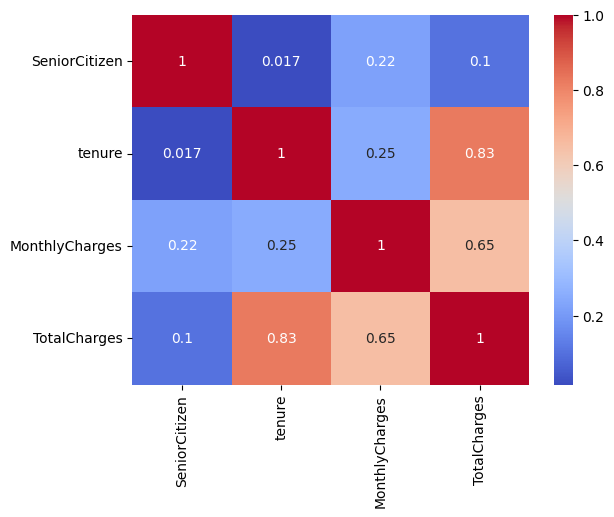

In [131]:
matrix_corr=df[num_cols].corr()
sns.heatmap(matrix_corr,annot=True,cmap='coolwarm')

Видно сильную зависимость между tenure и totalcharges. Стоит проверить VIF

In [132]:

X=df.select_dtypes(include=['int64', 'float64']).dropna()
vif_data=pd.DataFrame()
vif_data["feature"]=X.columns
vif_data["VIF"]=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

          feature       VIF
3    TotalCharges  8.085198
1          tenure  6.332737
2  MonthlyCharges  3.701617
0   SeniorCitizen  1.257569


Стоит удалить TotalCharges тк у него наибольшее значение VIF

In [133]:
df=df.drop('TotalCharges',axis=1)

# Кодирование призанков


In [134]:
df_new=df.copy()
for col in bin_cols:
  df_new[col]=df_new[col].map({'Yes':1,'No':0,'No internet service':0,'Male':0,'Female':1,'No phone service':0})

In [135]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes


In [136]:
cat_cols=df_new.select_dtypes(include=['object']).columns
cat_cols

Index(['InternetService', 'Contract', 'PaymentMethod'], dtype='object')

In [137]:
df_encoded=pd.get_dummies(df_new,columns=cat_cols,drop_first=True)
df_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,0,56.95,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,1,53.85,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,0,42.30,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,1,70.70,1,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,1,0,1,...,1,84.80,0,False,False,True,False,False,False,True
7039,1,0,1,1,72,1,1,0,1,1,...,1,103.20,0,True,False,True,False,True,False,False
7040,1,0,1,1,11,0,0,1,0,0,...,1,29.60,0,False,False,False,False,False,True,False
7041,0,1,1,0,4,1,1,0,0,0,...,1,74.40,1,True,False,False,False,False,False,True


# Обучение

Логистическая регрессия

In [138]:
# Нормируем признаки
scaled=StandardScaler()
scal_num=['MonthlyCharges','tenure']
df_scaled=df_encoded.copy()
df_scaled[scal_num]=scaled.fit_transform(df_scaled[scal_num])

In [139]:
X=df_scaled.drop('Churn',axis=1)
y=df_scaled['Churn']

In [140]:
X_train,X_test,y_train,y_test=train_test_split(X,y, stratify=y, random_state=42,test_size=0.2)

In [141]:
model=LogisticRegression(max_iter=500,random_state=42,class_weight='balanced')
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [142]:
y_proba=model.predict_proba(X_test)[:,1]

In [143]:
thresholds=np.arange(0.1, 0.9, 0.02)
lr_best_recall=0
best_threshold=0.5
lr_best_precision=0
for thresh in thresholds:
    y_pred_thresh=(y_proba >= thresh).astype(int)
    rec=recall_score(y_test, y_pred_thresh)
    prec=precision_score(y_test, y_pred_thresh)
    if rec>lr_best_recall:
        lr_best_recall=rec
        best_threshold=thresh
        if lr_best_precision<prec:
          lr_best_precision=prec
lr_roc_auc=roc_auc_score(y_test, y_proba)
print(f'Recall:   {lr_best_recall}')
print(f'Prec:   {lr_best_precision}')
print(f'ROC_AUC:   {lr_roc_auc}')

Recall:   0.9919786096256684
Prec:   0.3369663941871026
ROC_AUC:   0.8387920121935467


Дерево решений

In [144]:
X=df_encoded.drop('Churn',axis=1)
y=df_encoded['Churn']

In [145]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [146]:
model=RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [147]:
y_proba=model.predict_proba(X_test)[:,1]

In [148]:
thresholds=np.arange(0.1, 0.9, 0.02)
rf_best_recall=0
best_threshold=0.5
rf_best_precision=0
for thresh in thresholds:
    y_pred_thresh=(y_proba >= thresh).astype(int)
    rec=recall_score(y_test, y_pred_thresh)
    prec=precision_score(y_test, y_pred_thresh)
    if rec>rf_best_recall:
        rf_best_recall=rec
        best_threshold=thresh
        if rf_best_precision<prec:
          rf_best_precision=prec
rf_roc_auc=roc_auc_score(y_test, y_proba)
print(f'Recall:   {rf_best_recall}')
print(f'Prec:   {rf_best_precision}')
print(f'ROC_AUC:   {rf_roc_auc}')

Recall:   0.9358288770053476
Prec:   0.39281705948372614
ROC_AUC:   0.8264550879640393


Градиентный бустинг

In [149]:
df_grad=df.copy()

In [150]:
df_grad['Churn']=df_grad['Churn'].map({'Yes':1,'No':0})
cat_cols=df_grad.select_dtypes(include='object').columns

In [151]:
X=df_grad.drop('Churn',axis=1)
y=df_grad['Churn']

In [152]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [153]:
ratio=y_train.value_counts()[0]/y_train.value_counts()[1]
model=CatBoostClassifier(
    iterations=100,
    depth=7,
    learning_rate=0.1,
    cat_features=list(cat_cols),
    class_weights= [1,ratio],
    random_seed=42,
    verbose=False
)
model.fit(X_train,y_train)
y_proba=model.predict_proba(X_test)[:,1]

In [154]:
thresholds=np.arange(0.1, 0.9, 0.02)
cat_best_recall=0
best_threshold=0.5
cat_best_precision=0
for thresh in thresholds:
    y_pred_thresh=(y_proba >= thresh).astype(int)
    prec=precision_score(y_test, y_pred_thresh)
    rec=recall_score(y_test, y_pred_thresh)
    if rec>cat_best_recall:
        cat_best_recall=rec
        best_threshold=thresh
        if cat_best_precision<prec:
          cat_best_precision=prec
cat_roc_auc=roc_auc_score(y_test, y_proba)
print(f'Recall:   {cat_best_recall}')
print(f'Prec:   {cat_best_precision}')
print(f'ROC_AUC:   {cat_roc_auc}')

Recall:   0.983957219251337
Prec:   0.3458646616541353
ROC_AUC:   0.8467204009403496


In [155]:
explainer=shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
X_for_graf=X_test.copy()
best_model=model
X_best=X_train.copy()

Нейросеть

In [156]:
class Neiro(nn.Module):
  def __init__(self):
    super().__init__()
    self.net=nn.Sequential(
        nn.Linear(22,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64,32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Linear(32,2)
    )
  def forward(self,x):
    return self.net(x)

In [157]:
def train_step(model,optimizer,criterion,batch,device):
  X,y=batch
  X=X.to(device)
  y=y.to(device)

  model.train()
  optimizer.zero_grad()
  pred=model(X)
  loss=criterion(pred,y)
  loss.backward()
  optimizer.step()

  return loss.item()

In [158]:
def valid_step(model,criterion,batch,device):
  X,y=batch
  X=X.to(device)
  y=y.to(device)

  model.eval()
  with torch.no_grad():
    pred=model(X)
    loss=criterion(pred,y)
    ans=pred.argmax(dim=1).cpu().numpy()
  return ans,loss.item()


In [159]:
def train_epoch(model,optimizer,criterion,device,train_loader):
  model.train()
  loss=0.0
  for batch in tqdm(train_loader, desc='Train'):
    loss_step=train_step(model,optimizer,criterion,batch,device)
    loss+=loss_step
  return loss/len(train_loader)


In [160]:
def validation(model,criterion,device,val_loader):
  model.eval()
  total_loss=0.0
  all_preds = []
  all_labels = []
  for batch in tqdm(val_loader, desc='Val'):
      preds, loss=valid_step(model, criterion, batch, device)
      total_loss+=loss
      all_preds.append(preds)
      _, y=batch
      all_labels.append(y.numpy())
  all_preds=np.concatenate(all_preds)
  all_labels=np.concatenate(all_labels)
  rec=recall_score(all_labels, all_preds)
  return total_loss/len(val_loader),rec,all_preds


In [161]:
def train_and_validate(model,optimizer,criterion,device,train_loader,val_loader,epochs=100):
  model=model.to(device)
  metrics={'train_loss':[], 'val_loss':[],'rec':[]}
  model.eval()
  for epoch in tqdm(range(epochs)):
    train_loss=train_epoch(model,optimizer,criterion,device,train_loader)
    val_loss,val_rec,_=validation(model,criterion,device,val_loader)

    metrics['train_loss'].append(train_loss)
    metrics['val_loss'].append(val_loss)
    metrics['rec'].append(val_rec)

    print(f'Эпоха: {epoch+1}, loss на train: {train_loss}, loss на val:{val_loss}, recall:{val_rec}')

  return metrics

In [162]:
class ChurnDataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x.values if isinstance(x,pd.DataFrame) else x, dtype=torch.float32)
    if isinstance(y, pd.Series):
        y = y.values
    self.y = torch.tensor(y, dtype=torch.long)
  def __len__(self):
    return len(self.y)
  def __getitem__(self, index):
    return self.x[index],self.y[index]

In [163]:
df_encoded.shape

(7043, 23)

In [164]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
scaled=StandardScaler()
scal_num=['MonthlyCharges','tenure']
df_scaled=df_encoded.copy()
df_scaled[scal_num]=scaled.fit_transform(df_scaled[scal_num])


In [165]:
X=df_scaled.drop('Churn',axis=1)
y=df_scaled['Churn']
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

y_train = y_train.astype(np.int64)
y_val = y_val.astype(np.int64)
y_test = y_test.astype(np.int64)

batch_size=64
train_dataset=ChurnDataset(X_train,y_train)
val_dataset=ChurnDataset(X_val,y_val)
test_dataset=ChurnDataset(X_test,y_test)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=False)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weight_for_1=len(y_train)/(2*np.bincount(y_train)[1])
weight_for_0=len(y_train)/(2*np.bincount(y_train)[0])
class_weights=torch.tensor([weight_for_0, weight_for_1], dtype=torch.float32).to(device)

model=Neiro()
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss(weight=class_weights)


In [166]:
metrics=train_and_validate(model,optimizer,criterion,device,train_loader,val_loader,epochs=300)

Val: 100%|██████████| 17/17 [00:00<00:00, 3399.27it/s]


Эпоха: 1, loss на train: 0.5457862917429361, loss на val:0.5070269914234385, recall:0.8285714285714286


  1%|          | 2/300 [00:00<00:29, 10.11it/s]

Эпоха: 2, loss на train: 0.4993316790996454, loss на val:0.4974428730852464, recall:0.8321428571428572


Val: 100%|██████████| 17/17 [00:00<00:00, 3212.43it/s]


...

Эпоха: 298, loss на train: 0.2080500510548098, loss на val:1.2044064437641817, recall:0.6214285714285714


Val: 100%|██████████| 17/17 [00:00<00:00, 3316.58it/s]


Эпоха: 299, loss на train: 0.20070940357758305, loss на val:1.2159854980076061, recall:0.6285714285714286


100%|██████████| 300/300 [00:30<00:00,  9.91it/s]

Эпоха: 300, loss на train: 0.21268691070592746, loss на val:1.1893488571924322, recall:0.6392857142857142


In [167]:
test_loss, neiro_acc, test_preds = validation(model, criterion, device, test_loader)
model.eval()
with torch.no_grad():
  logits=model(torch.tensor(X_test.values, dtype=torch.float32).to(device))
  proba=torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

neiro_roc_auc = roc_auc_score(y_test, proba)
neiro_recall = recall_score(y_test, test_preds)
neiro_precision = precision_score(y_test, test_preds)
print()
print(f"Accuracy:  {neiro_acc}")
print(f"ROC-AUC:   {neiro_roc_auc}")
print(f"Recall:    {neiro_recall}")
print(f"Precision: {neiro_precision:}")

Val: 100%|██████████| 17/17 [00:00<00:00, 3185.45it/s]


Accuracy:  0.6619217081850534
ROC-AUC:   0.7880865465751916
Recall:    0.6619217081850534
Precision: 0.5269121813031161


# Выбор модели

Сравниваем модели

In [168]:
results = [
    {
        'Модель': 'Logistic Regression',
        'ROC-AUC': lr_roc_auc,
        'Recall (max)': lr_best_recall,
        'Precision (при max Recall)': lr_best_precision
    },
    {
        'Модель': 'Random Forest',
        'ROC-AUC': rf_roc_auc,
        'Recall (max)': rf_best_recall,
        'Precision (при max Recall)': rf_best_precision
    },
    {
        'Модель': 'CatBoost',
        'ROC-AUC': cat_roc_auc,
        'Recall (max)': cat_best_recall,
        'Precision (при max Recall)': cat_best_precision
    },
    {
        'Модель': 'Neural Network (PyTorch)',
        'ROC-AUC': neiro_roc_auc,
        'Recall (max)': neiro_recall,
        'Precision (при max Recall)': neiro_precision,
    }
]

df_results = pd.DataFrame(results)
df_results = df_results.round(4)

# Сортируем по ROC-AUC (по убыванию)
df_results = df_results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("Сравнение моделей по ключевым метрикам:\n")
print(df_results.to_string(index=False))

Сравнение моделей по ключевым метрикам:

                  Модель  ROC-AUC  Recall (max)  Precision (при max Recall)
                CatBoost   0.8467        0.9840                      0.3459
     Logistic Regression   0.8388        0.9920                      0.3370
           Random Forest   0.8265        0.9358                      0.3928
Neural Network (PyTorch)   0.7881        0.6619                      0.5269


Самая лучшая модель CatBoost, возьмем ее как основную. При ней ROC-AUC 0.84 и recall 0.98 - модель обладает высокой разделяющей способностью. Мы можем построить список клиентов от наиболее склонных к уходу к наименее склонным, и этот список будет хорошо отражать реальность. Это позволяет гибко настраивать стратегию удержания в зависимости от бюджета. Модель действует как очень чувствительная сигнализация. Мы практически не пропускаем клиентов, которые готовы нас покинуть. Отдел удержания может быть уверен: почти все "горячие" лиды окажутся в его списке.

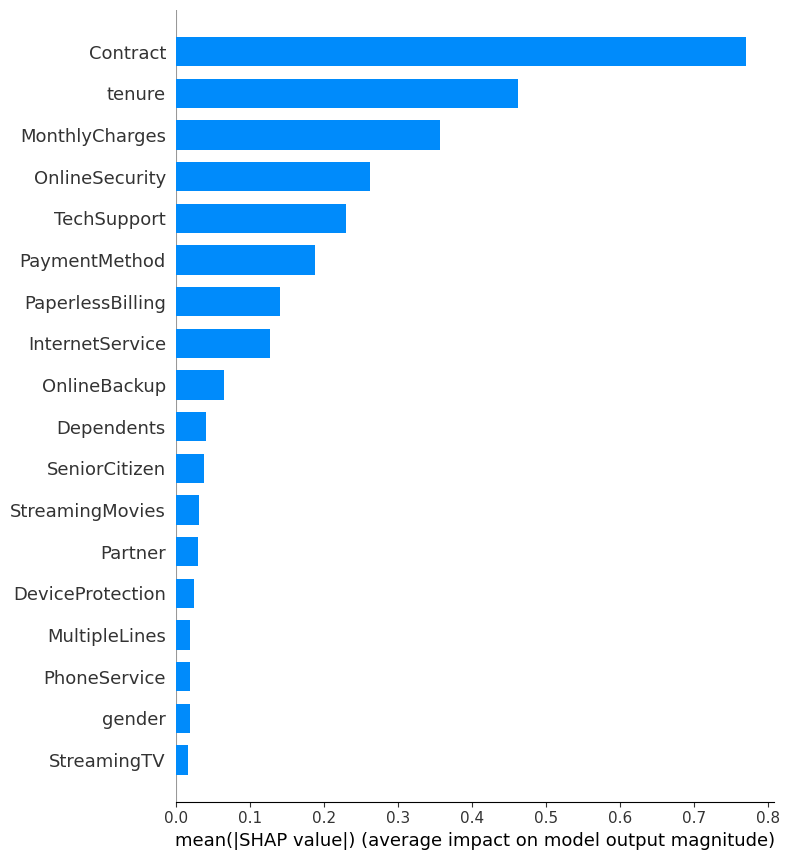

In [169]:
shap.summary_plot(shap_values, X_for_graf, plot_type="bar")

Признак Contract: Клиенты с помесячной оплатой имеют значительно более высокий риск оттока, чем пользователи годовых или двухлетних контрактов.
Совет:Запустить целевую кампанию по переводу на долгосрочные контракты. Клиентам с высоким скоринговым баллом (вероятность оттока > 0.7) предлагать скидку 15–20% при переходе на годовой тариф.


Признак tenure: Чем меньше клиент пользуется услугами, тем выше вероятность оттока. Наиболее уязвимы абоненты в первые 6–12 месяцев.
Совет: Разработать «Программу адаптации новых клиентов»: в первые 3 месяца – персональный менеджер, бесплатные дополнительные опции (антивирус, облачное хранилище)

# Сохраняем модель

In [170]:
import joblib

joblib.dump(best_model,'../models/catboost_model.pkl')
joblib.dump(X_best.columns.tolist(), '../models/feature_names.pkl')


['../models/feature_names.pkl']